# otwin 02 · When the process makes entropy

**Question.** A chemical reactor converts A into B and heats up. Energy is conserved — the
vessel is insulated — but the process is irreversible: entropy is produced and never
consumed. How do you write a model that *cannot* violate the second law, the way the models in
notebook 01 could not violate the first?

**What otwin does here.** `IrreversiblePHS` — a port-Hamiltonian system with an entropy
state, whose entropy production `σ` is computed by the library and checked non-negative on
every call. Built here in the form the literature uses, `ẋ = γ(x)·J∇H + g·u`, through
`IrreversiblePHS.from_modulated`.

**What you write yourself.** The thermodynamics: internal energy, chemical potentials,
temperature from entropy, the reaction rate. The same functions you would write for any
reactor model.

**What you will learn**

1. what an irreversible port-Hamiltonian system adds to a plain one — an entropy state and a modulating function
2. how to write the Ramírez–Maschke–Sbarbaro form directly, and what otwin then guarantees
3. that energy conservation *and* σ ≥ 0 are both structural — checked, not plotted
4. what goes wrong when you model the same reactor without an entropy state

*Pure simulation. Runtime ≈ 1 min. Opens in Colab.*


## Setup

In [1]:
# otwin from PyPI. This is the whole point of the notebook: no clone, no path
# surgery, no vendored copy of the model code.
!pip install -q otwin 2>/dev/null
import otwin, sys
print("otwin", otwin.__version__, "| python", sys.version.split()[0])


otwin 0.4.0 | python 3.12.3


In [2]:
# Inlined plotting style. Self-contained on purpose: nothing here imports
# from another file in this repository.
import os, json
import numpy as np, pandas as pd
import matplotlib; import matplotlib.pyplot as plt

TEAL, RED, SLATE, GRID, OBS = "#0E7C86", "#C1121F", "#4A5568", "#E5E9EC", "black"
BAND_ALPHA = 0.18
plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
    "font.family":"DejaVu Sans","axes.titlesize":13,"axes.labelsize":11,
    "xtick.labelsize":10,"ytick.labelsize":10,"legend.fontsize":10,
    "axes.grid":True,"grid.color":GRID,"grid.linewidth":0.8,"axes.axisbelow":True,
    "figure.dpi":110,"savefig.dpi":200,
})
FIGDIR="fig"; os.makedirs(FIGDIR, exist_ok=True)
def despine(ax):
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#333333"); ax.spines["bottom"].set_color("#333333")
def save(fig, name):
    p=os.path.join(FIGDIR, name if name.endswith(".png") else name+".png")
    fig.savefig(p, dpi=200, bbox_inches="tight"); plt.show(); print("saved", p); return p


## 1 · The reactor's thermodynamics — your code

State `x = (n_A, n_B, S)`: moles of A, moles of B, entropy. The Hamiltonian is the **internal
energy** `U`, because that is what must be conserved exactly in an insulated vessel, which turns
a structural claim into a number you can check. Its gradient is `(μ_A, μ_B, T)`: chemical
potentials and temperature.

Two things in this cell matter for what follows:

- `J3` is the fixed skew matrix that says "A turns into B, and the entropy state receives the
  affinity". It never changes.
- `gamma(x) = r/T` is the **modulating function**: reaction rate over temperature. It carries
  all the irreversibility. The rate is written so that its sign always matches the sign of the
  affinity — the reaction cannot run uphill.

The last line prints `σ = A·r/T` at the initial state: 0.109 W/K of entropy production.

In [3]:
import numpy as np, json
from otwin.model import PortHamiltonianSystem, IrreversiblePHS, integrate_phs
from scipy.integrate import solve_ivp

Rg = 8.314462618
J3 = np.array([[0., 0., -1.], [0., 0., 1.], [1., -1., 0.]])
assert np.allclose(J3, -J3.T)

cvA, cvB = 75.0, 80.0        # J/(mol K)
DMU0     = 2000.0            # mu_A0 - mu_B0, J/mol. Mildly exothermic, so equilibrium sits at
                             # PARTIAL conversion and the affinity can change sign.
Tref     = 350.0
k0, Ea   = 2.0, 20000.0      # 1/s, J/mol

def thermo(x):
    """From x = (n_A, n_B, S) recover T and the chemical potentials by inverting S(n,T)."""
    nA, nB, S = max(x[0], 1e-12), max(x[1], 1e-12), x[2]
    C = nA*cvA + nB*cvB; n = nA + nB
    S_mix = -Rg*(nA*np.log(nA/n) + nB*np.log(nB/n))
    T = Tref*np.exp((S - S_mix)/C)
    muA = cvA*(T-Tref) - cvA*T*np.log(T/Tref) + Rg*T*np.log(nA/n) + DMU0
    muB = cvB*(T-Tref) - cvB*T*np.log(T/Tref) + Rg*T*np.log(nB/n)
    return T, muA, muB

def rate(T, nA, nB, A):
    """Mass-action rate made thermodynamically consistent: sign(r) == sign(A) identically."""
    return k0*np.exp(-Ea/(Rg*T))*(nA + nB)*(1.0 - np.exp(-A/(Rg*T)))/2.0

def gamma(x):
    T, muA, muB = thermo(x); return rate(T, x[0], x[1], muA-muB)/T

def U(x):
    T, _, _ = thermo(x)
    return x[0]*cvA*(T-Tref) + x[1]*cvB*(T-Tref) + x[0]*DMU0
def gradU(x):
    T, muA, muB = thermo(x); return np.array([muA, muB, T])
def sigma_of(x):
    T, muA, muB = thermo(x); A = muA-muB
    return A*rate(T, x[0], x[1], A)/T

x0 = np.array([8.0, 2.0, 0.0])
print("gamma(x0) = %.6e   sigma(x0) = %.6e W/K" % (gamma(x0), sigma_of(x0)))

gamma(x0) = 1.866524e-05   sigma(x0) = 1.086656e-01 W/K


## 2 · The irreversible system, in the form the literature writes it

$$\dot x = \gamma(x)\,J\,\nabla U + g\,u, \qquad \sigma = \gamma \cdot A \ge 0$$

`IrreversiblePHS.from_modulated` takes exactly the pieces from section 1 — `U`, its gradient,
the entropy `S`, the skew `J`, the modulating `γ`, the port `g` — and builds the system. The
heat port is closed (`g = 0`): adiabatic.

*Look at:* `check_structure` now returns **five** verdicts. The two from notebook 01, and three
new ones: is the coupling positive semi-definite, is `σ ≥ 0` at this state, and is energy
conserved by the structure (`∇Uᵀ L ∇S = 0`). All three are properties of the object, not of a
particular simulation.

In [4]:
reactor = IrreversiblePHS.from_modulated(
    H=U, grad_H=gradU,
    S=lambda x: float(x[2]), grad_S=lambda x: np.array([0.0, 0.0, 1.0]),
    J=lambda x: J3, gamma=gamma,
    g=lambda x: np.zeros((3, 1)),          # adiabatic: the heat port is shut
    n_states=3, n_inputs=1)

print(type(reactor).__name__)
for k, v in reactor.check_structure(x0).items():
    print("   %-18s %s" % (k, v))


ModulatedIPHS
   J_skew             (np.True_, 0.0)
   R_psd              (True, 0.0)
   gamma_finite       (True, 1.8665238092668528e-05)
   sigma_nonneg       (True, 0.10866560392467277)
   energy_conserved   (True, -1.5422795492917121e-15)


## 3 · Run it: energy stays, entropy rises

Integrate 4000 s and track two quantities: internal energy (must be constant) and entropy
production (must be non-negative). `entropy_production` is computed by otwin from the
structure, not by this notebook.

*Look at:* the energy drift is ~10⁻¹³ relative — machine precision — and the smallest σ over
the whole run is ~10⁻¹⁴, positive. Not one step below zero. Temperature rises 12 K; the
reaction stops at 58.5 % conversion, where the affinity crosses zero — chemical equilibrium,
found by the thermodynamics rather than imposed.

In [5]:
s = solve_ivp(lambda tt, x: reactor.dynamics(x, np.zeros(1), tt), (0, 4000), x0,
              rtol=1e-12, atol=1e-14, max_step=2.0, method="LSODA")
X = s.y; tt = s.t
Us  = np.array([U(X[:, k]) for k in range(X.shape[1])])
sig = np.array([reactor.entropy_production(X[:, k]) for k in range(X.shape[1])])
Ts  = np.array([thermo(X[:, k])[0] for k in range(X.shape[1])])

cstr = dict(energy_drift=float(np.max(np.abs(Us-Us[0]))/abs(Us[0])),
            min_sigma=float(sig.min()), mean_sigma=float(sig.mean()),
            frac_negative=float(np.mean(sig < 0)),
            entropy_increase_J_per_K=float(X[2, -1]-X[2, 0]),
            T_initial=float(Ts[0]), T_final=float(Ts[-1]),
            conversion=float(1-X[0, -1]/X[0, 0]))
for k, v in cstr.items(): print("  %-26s %s" % (k, f"{v:.6g}"))


  energy_drift               1.3622e-13
  min_sigma                  4.62318e-14
  mean_sigma                 0.0113013
  frac_negative              0
  entropy_increase_J_per_K   38.979
  T_initial                  331.354
  T_final                    343.862
  conversion                 0.585133


## 4 · The negative control: the same reactor without an entropy state

Most reactor models are written like this: first-order decay `dn_A/dt = −k·n_A` at a fixed
rate constant, temperature from an energy balance, no entropy anywhere. It looks fine. It is
also a perfectly valid *plain* PHS — `J` skew, `R` PSD — and otwin would accept it.

*Look at:* nothing stops this model pushing the reaction past equilibrium. Once the affinity
changes sign, the entropy production it implies is negative for **91 % of the run**. The
second law is not a property of a plain PHS. Only `IrreversiblePHS` carries it, and only
because the coupling is checked. Choosing the right class is on you; the library cannot tell
you your reactor is irreversible.

In [6]:
def f_plain(t, y):
    nA, nB, T = y
    r = k0*np.exp(-Ea/(Rg*T))*nA                 # forward only: no affinity, no back reaction
    return [-r, r, r*DMU0/(nA*cvA + nB*cvB)]

sp = solve_ivp(f_plain, (0, 4000), [8.0, 2.0, 350.0], rtol=1e-11, atol=1e-13, max_step=2.0)
nAp, nBp, Tp = sp.y; ntot = nAp + nBp
muAp = cvA*(Tp-Tref) - cvA*Tp*np.log(Tp/Tref) + Rg*Tp*np.log(np.clip(nAp, 1e-12, None)/ntot) + DMU0
muBp = cvB*(Tp-Tref) - cvB*Tp*np.log(Tp/Tref) + Rg*Tp*np.log(np.clip(nBp, 1e-12, None)/ntot)
Ap = muAp - muBp
sigp = Ap*(k0*np.exp(-Ea/(Rg*Tp))*nAp)/Tp

viol = dict(min_entropy_production_W_per_K=float(sigp.min()),
            fraction_violating=float(np.mean(sigp < 0)),
            first_violation_time_s=float(sp.t[np.argmax(sigp < 0)]) if (sigp < 0).any() else None)
print(json.dumps(viol, indent=2))


{
  "min_entropy_production_W_per_K": -0.03850958093376531,
  "fraction_violating": 0.9076846307385229,
  "first_violation_time_s": 364.80750382121704
}


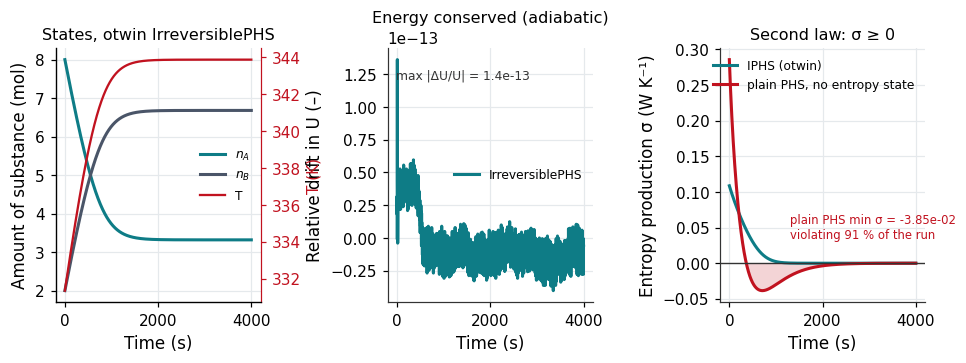

saved fig/f_otwin02_iphs.png


'fig/f_otwin02_iphs.png'

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.0)); fig.subplots_adjust(wspace=0.62)
ax = axes[0]
ax.plot(tt, X[0], "-", color=TEAL, lw=2.0, label="$n_A$")
ax.plot(tt, X[1], "-", color=SLATE, lw=2.0, label="$n_B$")
ax2 = ax.twinx(); ax2.plot(tt, Ts, "-", color=RED, lw=1.5, label="T")
ax2.set_ylabel("T (K)", color=RED, fontsize=10); ax2.tick_params(axis="y", colors=RED); ax2.grid(False)
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_color(RED)
ax.set_xlabel("Time (s)"); ax.set_ylabel("Amount of substance (mol)")
ax.set_title("States, otwin IrreversiblePHS", fontsize=10.5)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1+h2, l1+l2, frameon=False, fontsize=8, loc="center right"); despine(ax)

ax = axes[1]
ax.plot(tt, (Us-Us[0])/abs(Us[0]), "-", color=TEAL, lw=2.0, label="IrreversiblePHS")
ax.set_xlabel("Time (s)"); ax.set_ylabel("Relative drift in U (–)")
ax.set_title("Energy conserved (adiabatic)", fontsize=10.5)
ax.text(0.04, 0.92, "max |ΔU/U| = %.1e" % cstr["energy_drift"],
        transform=ax.transAxes, fontsize=8.0, color="#333", va="top")
ax.legend(frameon=False, fontsize=8); despine(ax)

ax = axes[2]
ax.plot(tt, sig, "-", color=TEAL, lw=2.0, label="IPHS (otwin)")
ax.plot(sp.t, sigp, "-", color=RED, lw=2.0, label="plain PHS, no entropy state")
ax.fill_between(sp.t, np.minimum(sigp, 0), 0, color=RED, alpha=0.18, lw=0)
ax.axhline(0, color="#333333", lw=0.9)
ax.set_xlabel("Time (s)"); ax.set_ylabel("Entropy production σ (W K⁻¹)")
ax.set_title("Second law: σ ≥ 0", fontsize=10.5)
ax.text(0.34, 0.35, "plain PHS min σ = %.2e\nviolating %.0f %% of the run"
        % (sigp.min(), 100*np.mean(sigp < 0)), transform=ax.transAxes, fontsize=7.6,
        color=RED, va="top")
ax.legend(frameon=False, fontsize=8, loc="upper right"); despine(ax)
save(fig, "f_otwin02_iphs")

## 5 · Change one thing

- **Break the rate.** The cell below replaces `rate()` with plain mass action that ignores the
  affinity. It builds, and at the initial state it passes. Then it is integrated — and once the
  reaction runs past equilibrium, otwin **raises** rather than returning a plausible number.
  Read the error: it says what is wrong and how to fix it.
- **Open the heat port.** Give `g` a third-row entry of 1 and pass a cooling flow `u(t, x)`
  — the port-law idea from notebook 01 §5. Energy is no longer conserved (it leaves through
  the port) but σ stays ≥ 0. That is the difference between the first law and the second.
- **Make it endothermic.** Set `DMU0 = -2000`. Temperature falls, conversion changes, σ still ≥ 0.

In [8]:
# Try it: the same structure with a rate that ignores the affinity.
def gamma_naive(x):
    T, muA, muB = thermo(x)
    return k0*np.exp(-Ea/(Rg*T))*x[0]/T          # forward-only mass action, no back reaction
naive = IrreversiblePHS.from_modulated(H=U, grad_H=gradU, S=lambda x: float(x[2]),
    grad_S=lambda x: np.array([0.0, 0.0, 1.0]), J=lambda x: J3, gamma=gamma_naive,
    g=lambda x: np.zeros((3, 1)), n_states=3, n_inputs=1)
print("at x0 the naive rate looks fine:", naive.check_structure(x0)["sigma_nonneg"])
try:
    solve_ivp(lambda tt, x: naive.dynamics(x, np.zeros(1), tt), (0, 4000), x0, rtol=1e-10, atol=1e-12, max_step=2.0)
except ValueError as e:
    print("\nintegration stopped by otwin:\n  ", str(e)[:230], "...")


at x0 the naive rate looks fine: (True, 0.197766187313263)

integration stopped by otwin:
   modulating function gamma(x) violates the second law at this state: entropy production sigma = -4.138e-05 < 0. In the RMS form sigma >= 0 is a property of gamma, not of the structure -- build the rate from the affinity so that sig ...


## What you learned

- An irreversible PHS is a plain PHS plus an entropy state and a modulating function; the
  entropy production is then a property of the structure.
- `from_modulated` builds the form the literature uses; the library derives the rest.
- Energy conservation and σ ≥ 0 are both *checked* — five verdicts from `check_structure`.
- A reactor modelled without an entropy state can violate the second law and nothing in a
  plain PHS will notice. Class choice is the modelling decision.

**Next:** [notebook 03](otwin_03_scoring_a_forecast.ipynb) — from physics to forecasts, and how
to score one honestly.

---
*For CI, not for you.*

In [9]:
# Headline numbers: computed in THIS notebook against the value recorded in the
# original notebook series (results_experiments.json).
REFERENCE = [
    ("X3 energy drift (order of magnitude)",   float(cstr["energy_drift"]),   1.0440251463353387e-13, 1e1),
    ("X3 min entropy production (W/K)",          float(cstr["min_sigma"]),      4.6231819967485624e-14, 2e-2),
    ("X3 fraction of steps with negative sigma", float(cstr["frac_negative"]),  0.0,                    1e-9),
    ("X3 plain-PHS min entropy production (W/K)",float(viol["min_entropy_production_W_per_K"]), -0.03850958093376531, 2e-2),
    ("X3 final temperature (K)",                 float(cstr["T_final"]),        343.86208,              1e-4),
]
print(f"{'quantity':<52} {'this run':>14}  {'reference':>14}  {'match':>6}")
print("-"*94)
_bad = []
for name, got, ref, tol in REFERENCE:
    if isinstance(got, float) and isinstance(ref, float):
        ok = abs(got-ref) <= max(1e-12, tol*max(abs(ref), 1e-12))
        shown = f"{got:>14.6g}  {ref:>14.6g}"
    else:
        ok = (got == ref); shown = f"{str(got):>14}  {str(ref):>14}"
    print(f"{name:<52} {shown}  {'yes' if ok else 'NO':>6}")
    if not ok: _bad.append(name)
print()
print("all headline numbers reproduced through the otwin API" if not _bad else f"DRIFTED: {_bad}")


quantity                                                   this run       reference   match
----------------------------------------------------------------------------------------------
X3 energy drift (order of magnitude)                     1.3622e-13     1.04403e-13     yes
X3 min entropy production (W/K)                         4.62318e-14     4.62318e-14     yes
X3 fraction of steps with negative sigma                          0               0     yes
X3 plain-PHS min entropy production (W/K)                -0.0385096      -0.0385096     yes
X3 final temperature (K)                                    343.862         343.862     yes

all headline numbers reproduced through the otwin API


In [10]:
# Regression test. Fails loudly if a headline number has drifted.
assert not _bad, f"headline numbers drifted from the original notebooks: {_bad}"
print("regression test passed")


regression test passed
